# Indian Data & Tech Jobs — EDA (10K Job Postings)

**Dataset:** `jobs_10k.csv` — 10,000 data/tech job postings across India with salary ranges, experience requirements, seniority, location, and 27 binary skill-demand flags (SQL, Python, cloud platforms, BI tools, ML frameworks, etc.)

**Goals of this notebook:**
1. Clean and validate the dataset
2. Explore distributions, missingness, and relationships
3. Extract actionable insights on salary, skills demand, and market trends

**Author:** Bhumit Vasava


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/jobs_10k.csv')
df.head()

,job_id,job_title,company,city,state,job_type,date_posted,salary_min,salary_max,role_category,experience_min,experience_max,seniority,sql,python,power_bi,tableau,excel,r_lang,dax,etl,statistics,git,looker,spark,snowflake,azure,aws,gcp,tensorflow,pytorch,kafka,airflow,dbt,docker,nosql,hadoop,sas,scala,ml
0,IND_01644,ML Ops Specialist,Flipkart,Mumbai,Maharashtra,Contractual,2026-03-06,2775000.0,3197563.0,ML Engineer,3.0,5.0,Mid,1,1,0,0,0,0,0,1,0,0,0,1,0,1,1,0,1,1,0,0,0,1,1,1,0,0,1
1,IND_02704,Data Scientist - Risk,JP Morgan,Bangalore,Karnataka,Permanent,2026-05-29,NaN,NaN,Data Scientist,3.0,5.0,Mid,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1
2,IND_04005,Operations Data Analyst,HCL Technologies,Mumbai,Maharashtra,Full-time,2026-05-20,NaN,NaN,Data Analyst,5.0,8.0,Mid,1,1,1,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
3,IND_07803,Data Analyst - Supply Chain,NIIT Technologies,Hyderabad,Telangana,Full-time,2026-06-21,525000.0,669277.0,Data Analyst,1.0,4.0,Junior,1,1,1,1,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,IND_00948,MLOps Engineer,Accenture AI,Bangalore,Karnataka,Full-time,2026-04-20,NaN,NaN,ML Engineer,9.0,12.0,Senior,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,1,0,0,1,1,0,0,0,1


## 1. Initial Inspection

In [2]:
print(f"Shape: {df.shape}")
df.info()

Shape: (10000, 40)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   job_id          10000 non-null  str    
 1   job_title       10000 non-null  str    
 2   company         10000 non-null  str    
 3   city            10000 non-null  str    
 4   state           10000 non-null  str    
 5   job_type        10000 non-null  str    
 6   date_posted     10000 non-null  str    
 7   salary_min      2983 non-null   float64
 8   salary_max      2983 non-null   float64
 9   role_category   10000 non-null  str    
 10  experience_min  9196 non-null   float64
 11  experience_max  9196 non-null   float64
 12  seniority       9196 non-null   str    
 13  sql             10000 non-null  int64  
 14  python          10000 non-null  int64  
 15  power_bi        10000 non-null  int64  
 16  tableau         10000 non-null  int64  
 17  excel           10000 no

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,10000,10000,IND_01644,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,10000,123,BI Engineer,159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company,10000,198,Mphasis,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,10000,6,Bangalore,2209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,10000,5,Maharashtra,3122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_type,10000,5,Full-time,5523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_posted,10000,120,2026-05-21,105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_min,2983.0,NaN,NaN,NaN,1573860.207844,1005972.877442,280000.0,825000.0,1300000.0,2050000.0,5975000.0
salary_max,2983.0,NaN,NaN,NaN,2158691.090513,1389777.150821,324340.0,1142530.5,1775625.0,2785897.0,8884409.0
role_category,10000,5,Data Analyst,2810,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning

### 2.1 Missing values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')

,missing_count,missing_pct
salary_min,7017,70.17
salary_max,7017,70.17
experience_min,804,8.04
experience_max,804,8.04
seniority,804,8.04


**Observations:**
- `salary_min` / `salary_max` are missing in ~70% of postings — this is very likely "salary not disclosed" rather than a data error, so we should **not** drop these rows (that would remove most of the dataset). Instead we'll keep a boolean flag `salary_disclosed` and analyze salary only on the subset that has it.
- `experience_min` / `experience_max` / `seniority` are missing together in ~8% of rows (likely postings that didn't specify experience) — we'll flag these too rather than dropping.


In [5]:
df['salary_disclosed'] = df['salary_min'].notnull()
df['experience_disclosed'] = df['experience_min'].notnull()

print("Rows with salary disclosed:", df['salary_disclosed'].sum())
print("Rows with experience disclosed:", df['experience_disclosed'].sum())

Rows with salary disclosed: 2983
Rows with experience disclosed: 9196


### 2.2 Duplicates

In [6]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated job_id:", df['job_id'].duplicated().sum())
# No duplicates found - job_id is a clean unique key

Fully duplicated rows: 0
Duplicated job_id: 0


### 2.3 Logical consistency checks

In [7]:
# salary_min should never exceed salary_max, same for experience
bad_salary = (df['salary_min'] > df['salary_max']).sum()
bad_experience = (df['experience_min'] > df['experience_max']).sum()
print(f"Rows where salary_min > salary_max: {bad_salary}")
print(f"Rows where experience_min > experience_max: {bad_experience}")
# Both clean - no logical errors found

Rows where salary_min > salary_max: 0
Rows where experience_min > experience_max: 0


### 2.4 Data types & derived columns

In [8]:
df['date_posted'] = pd.to_datetime(df['date_posted'])
df['salary_avg'] = (df['salary_min'] + df['salary_max']) / 2
df['experience_avg'] = (df['experience_min'] + df['experience_max']) / 2
df['post_month'] = df['date_posted'].dt.to_period('M').astype(str)
df['post_week'] = df['date_posted'].dt.isocalendar().week

skill_cols = ['sql','python','power_bi','tableau','excel','r_lang','dax','etl','statistics','git',
              'looker','spark','snowflake','azure','aws','gcp','tensorflow','pytorch','kafka',
              'airflow','dbt','docker','nosql','hadoop','sas','scala','ml']

df['total_skills_required'] = df[skill_cols].sum(axis=1)
df.head()

,job_id,job_title,company,city,state,job_type,date_posted,salary_min,salary_max,role_category,experience_min,experience_max,seniority,sql,python,power_bi,tableau,excel,r_lang,dax,etl,statistics,git,looker,spark,snowflake,azure,aws,gcp,tensorflow,pytorch,kafka,airflow,dbt,docker,nosql,hadoop,sas,scala,ml,salary_disclosed,experience_disclosed,salary_avg,experience_avg,post_month,post_week,total_skills_required
0,IND_01644,ML Ops Specialist,Flipkart,Mumbai,Maharashtra,Contractual,2026-03-06,2775000.0,3197563.0,ML Engineer,3.0,5.0,Mid,1,1,0,0,0,0,0,1,0,0,0,1,0,1,1,0,1,1,0,0,0,1,1,1,0,0,1,True,True,2986281.5,4.0,2026-03,10,12
1,IND_02704,Data Scientist - Risk,JP Morgan,Bangalore,Karnataka,Permanent,2026-05-29,NaN,NaN,Data Scientist,3.0,5.0,Mid,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,False,True,NaN,4.0,2026-05,22,8
2,IND_04005,Operations Data Analyst,HCL Technologies,Mumbai,Maharashtra,Full-time,2026-05-20,NaN,NaN,Data Analyst,5.0,8.0,Mid,1,1,1,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,False,True,NaN,6.5,2026-05,21,8
3,IND_07803,Data Analyst - Supply Chain,NIIT Technologies,Hyderabad,Telangana,Full-time,2026-06-21,525000.0,669277.0,Data Analyst,1.0,4.0,Junior,1,1,1,1,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,True,True,597138.5,2.5,2026-06,25,8
4,IND_00948,MLOps Engineer,Accenture AI,Bangalore,Karnataka,Full-time,2026-04-20,NaN,NaN,ML Engineer,9.0,12.0,Senior,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,1,0,0,1,1,0,0,0,1,False,True,NaN,10.5,2026-04,17,9


### 2.5 Categorical value checks

In [9]:
for col in ['job_type', 'role_category', 'seniority', 'state', 'city']:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts())


job_type (5 unique values):
job_type
Full-time      5523
Permanent      2477
Contractual     997
Temporary       505
Part-time       498
Name: count, dtype: int64

role_category (5 unique values):
role_category
Data Analyst      2810
Data Engineer     2566
Data Scientist    2206
BI Developer      1287
ML Engineer       1131
Name: count, dtype: int64

seniority (4 unique values):
seniority
Mid        3471
Junior     2536
Senior     2184
Fresher    1005
Name: count, dtype: int64

state (5 unique values):
state
Maharashtra    3122
Karnataka      2209
Telangana      1610
Tamil Nadu     1540
Haryana        1519
Name: count, dtype: int64

city (6 unique values):
city
Bangalore    2209
Mumbai       1673
Hyderabad    1610
Chennai      1540
Gurugram     1519
Pune         1449
Name: count, dtype: int64


No inconsistent category labels (typos, casing issues) were found — categories are already clean and standardized.

**Cleaning summary:** dataset had no duplicates and no logical errors. Missingness in salary/experience is structural (undisclosed), so we retained all 10,000 rows and added `salary_disclosed` / `experience_disclosed` flags plus derived columns (`salary_avg`, `experience_avg`, `total_skills_required`, `post_month`) for analysis.


## 3. Exploratory Data Analysis

### 3.1 Job postings by role, city, and job type

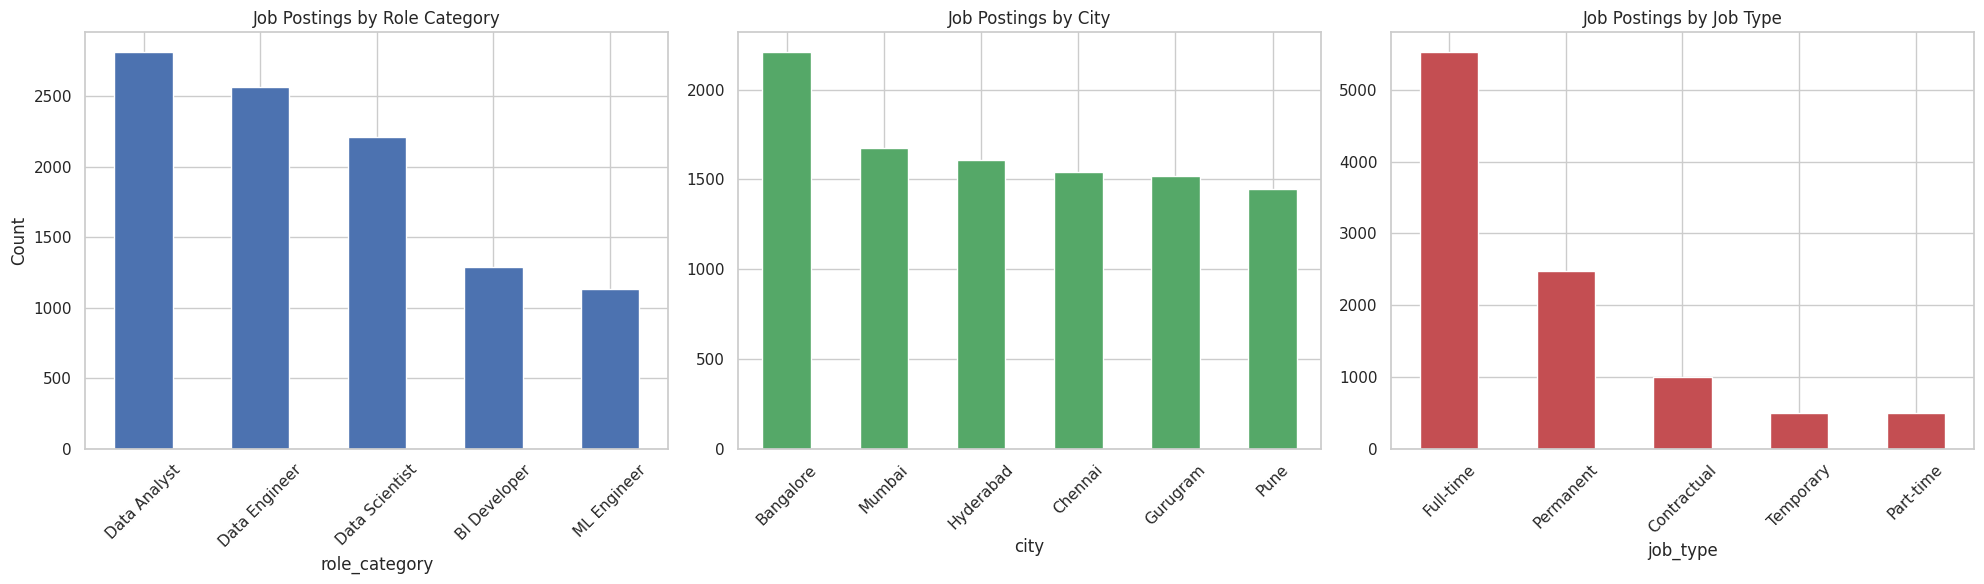

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

df['role_category'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Job Postings by Role Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['city'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Job Postings by City')
axes[1].tick_params(axis='x', rotation=45)

df['job_type'].value_counts().plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('Job Postings by Job Type')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/01_postings_overview.png', dpi=120)
plt.show()

### 3.2 Salary distribution (where disclosed)

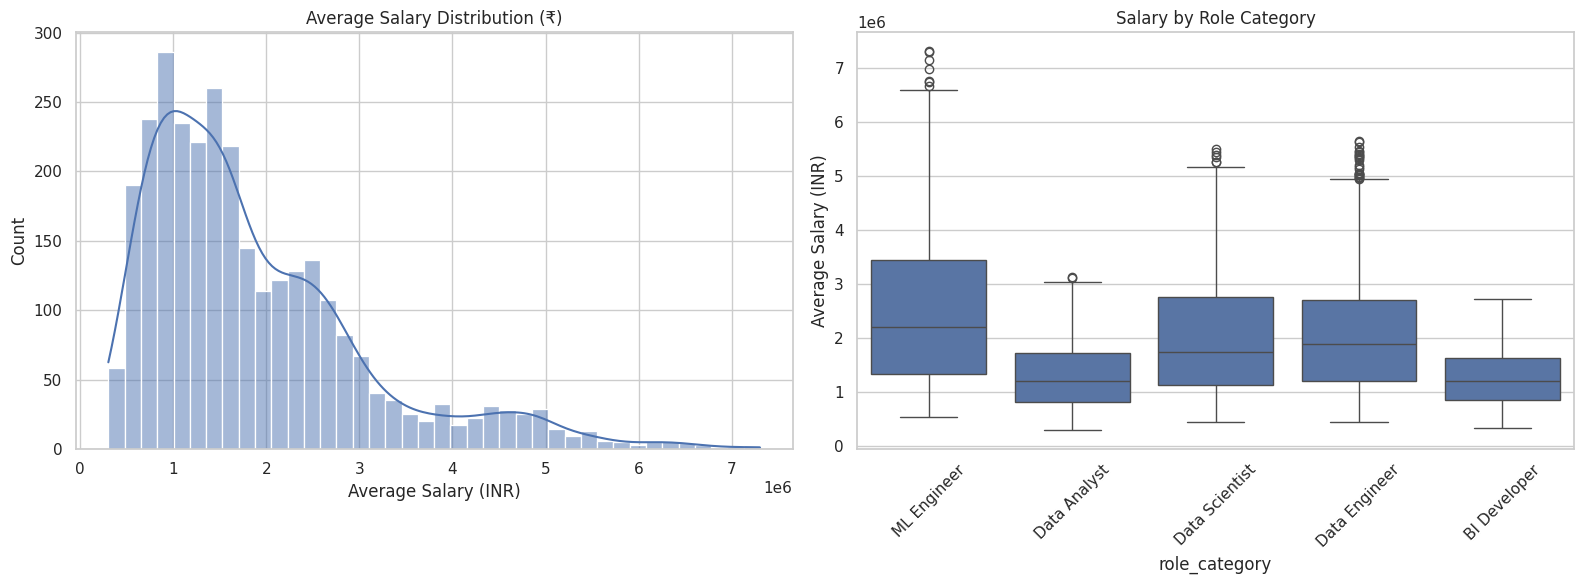

In [11]:
salary_df = df[df['salary_disclosed']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(salary_df['salary_avg'], bins=40, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Average Salary Distribution (₹)')
axes[0].set_xlabel('Average Salary (INR)')

sns.boxplot(data=salary_df, x='role_category', y='salary_avg', ax=axes[1])
axes[1].set_title('Salary by Role Category')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Average Salary (INR)')

plt.tight_layout()
plt.savefig('../outputs/02_salary_distribution.png', dpi=120)
plt.show()

In [12]:
salary_df.groupby('role_category')['salary_avg'].agg(['mean','median','min','max','count']).sort_values('median', ascending=False).round(0)

,mean,median,min,max,count
role_category,,,,,
ML Engineer,2629532.0,2199234.0,541106.0,7304704.0,365
Data Engineer,2151525.0,1896549.0,442504.0,5645648.0,772
Data Scientist,2083446.0,1745295.0,447453.0,5504915.0,662
BI Developer,1282761.0,1201468.0,334630.0,2719474.0,381
Data Analyst,1342927.0,1198341.0,302170.0,3123451.0,803


### 3.3 Salary by seniority level

/tmp/ipykernel_591/544740879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=salary_df, x='seniority', y='salary_avg', order=order, palette='viridis')


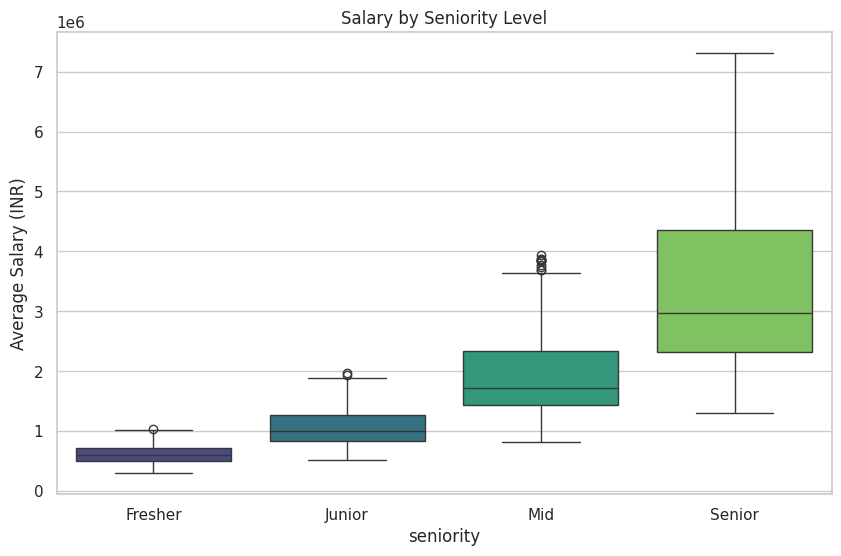

seniority
Fresher     602611.00
Junior     1013871.75
Mid        1726962.00
Senior     2966886.50
Name: salary_avg, dtype: float64

In [13]:
order = ['Fresher', 'Junior', 'Mid', 'Senior']
plt.figure(figsize=(10,6))
sns.boxplot(data=salary_df, x='seniority', y='salary_avg', order=order, palette='viridis')
plt.title('Salary by Seniority Level')
plt.ylabel('Average Salary (INR)')
plt.savefig('../outputs/03_salary_by_seniority.png', dpi=120)
plt.show()

salary_df.groupby('seniority')['salary_avg'].median().reindex(order)

### 3.4 Salary by city

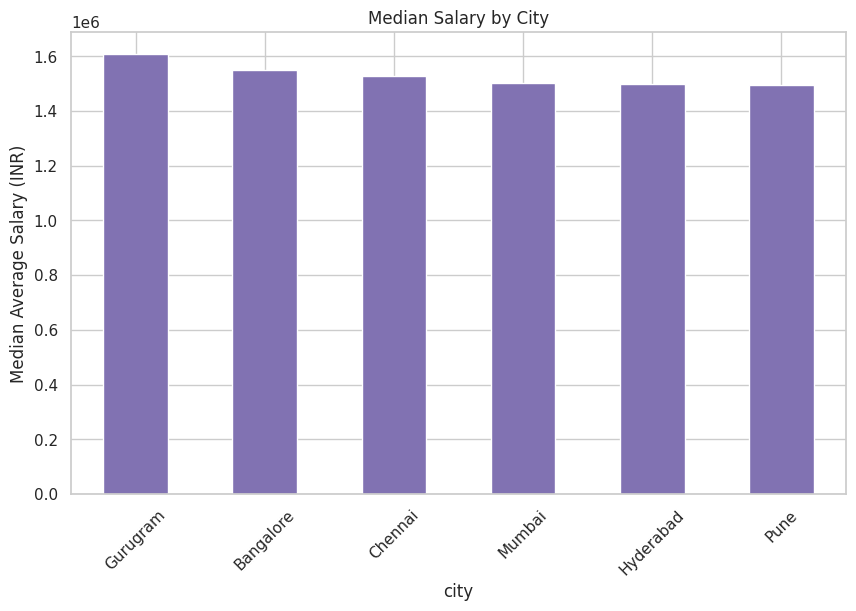

city
Gurugram     1607959.0
Bangalore    1547695.0
Chennai      1526044.0
Mumbai       1502287.5
Hyderabad    1497869.0
Pune         1494436.5
Name: salary_avg, dtype: float64

In [14]:
city_salary = salary_df.groupby('city')['salary_avg'].median().sort_values(ascending=False)
plt.figure(figsize=(10,6))
city_salary.plot(kind='bar', color='#8172B2')
plt.title('Median Salary by City')
plt.ylabel('Median Average Salary (INR)')
plt.xticks(rotation=45)
plt.savefig('../outputs/04_salary_by_city.png', dpi=120)
plt.show()
city_salary

### 3.5 Experience vs Salary relationship

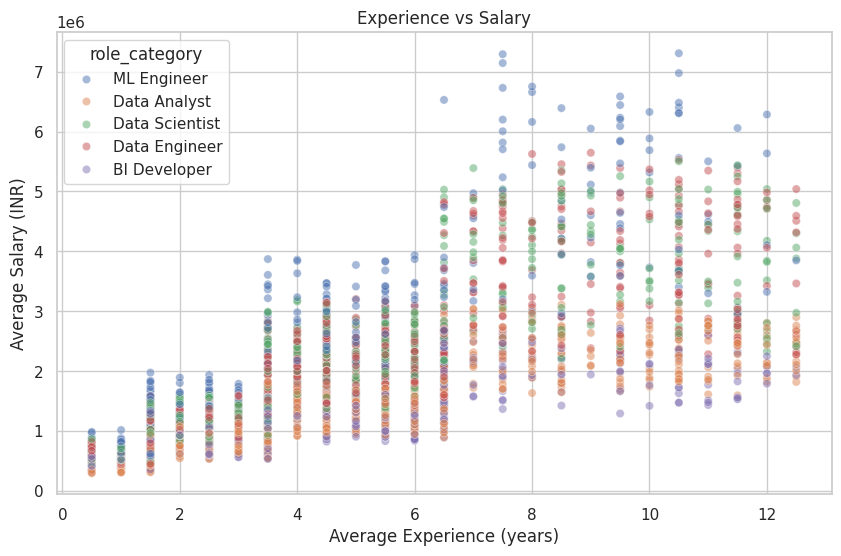

Correlation (experience_avg vs salary_avg): 0.723


In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=salary_df, x='experience_avg', y='salary_avg', hue='role_category', alpha=0.5)
plt.title('Experience vs Salary')
plt.xlabel('Average Experience (years)')
plt.ylabel('Average Salary (INR)')
plt.savefig('../outputs/05_experience_vs_salary.png', dpi=120)
plt.show()

print("Correlation (experience_avg vs salary_avg):", salary_df['experience_avg'].corr(salary_df['salary_avg']).round(3))

### 3.6 Most in-demand skills (overall)

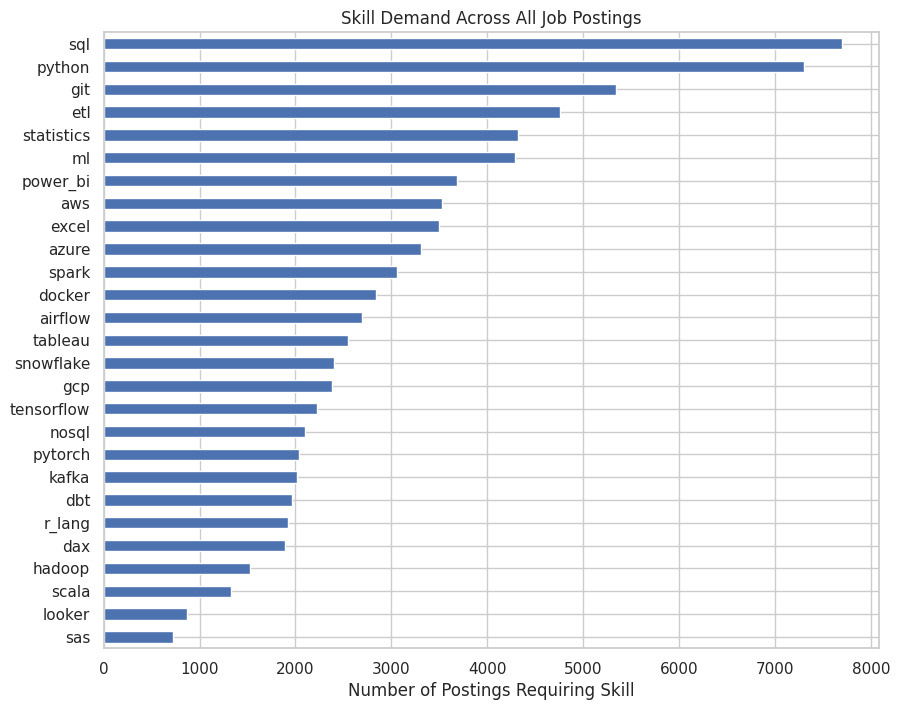

sql           76.9
python        73.0
git           53.4
etl           47.6
statistics    43.2
ml            42.9
power_bi      36.8
aws           35.3
excel         34.9
azure         33.1
spark         30.6
docker        28.4
airflow       27.0
tableau       25.5
snowflake     24.0
gcp           23.8
tensorflow    22.2
nosql         21.0
pytorch       20.4
kafka         20.1
dbt           19.6
r_lang        19.2
dax           18.9
hadoop        15.2
scala         13.3
looker         8.7
sas            7.2
Name: pct_of_postings, dtype: float64

In [16]:
skill_demand = df[skill_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(10,8))
skill_demand.plot(kind='barh', color='#4C72B0')
plt.title('Skill Demand Across All Job Postings')
plt.xlabel('Number of Postings Requiring Skill')
plt.gca().invert_yaxis()
plt.savefig('../outputs/06_skill_demand.png', dpi=120)
plt.show()

(skill_demand / len(df) * 100).round(1).rename('pct_of_postings')

### 3.7 Top skills by role category

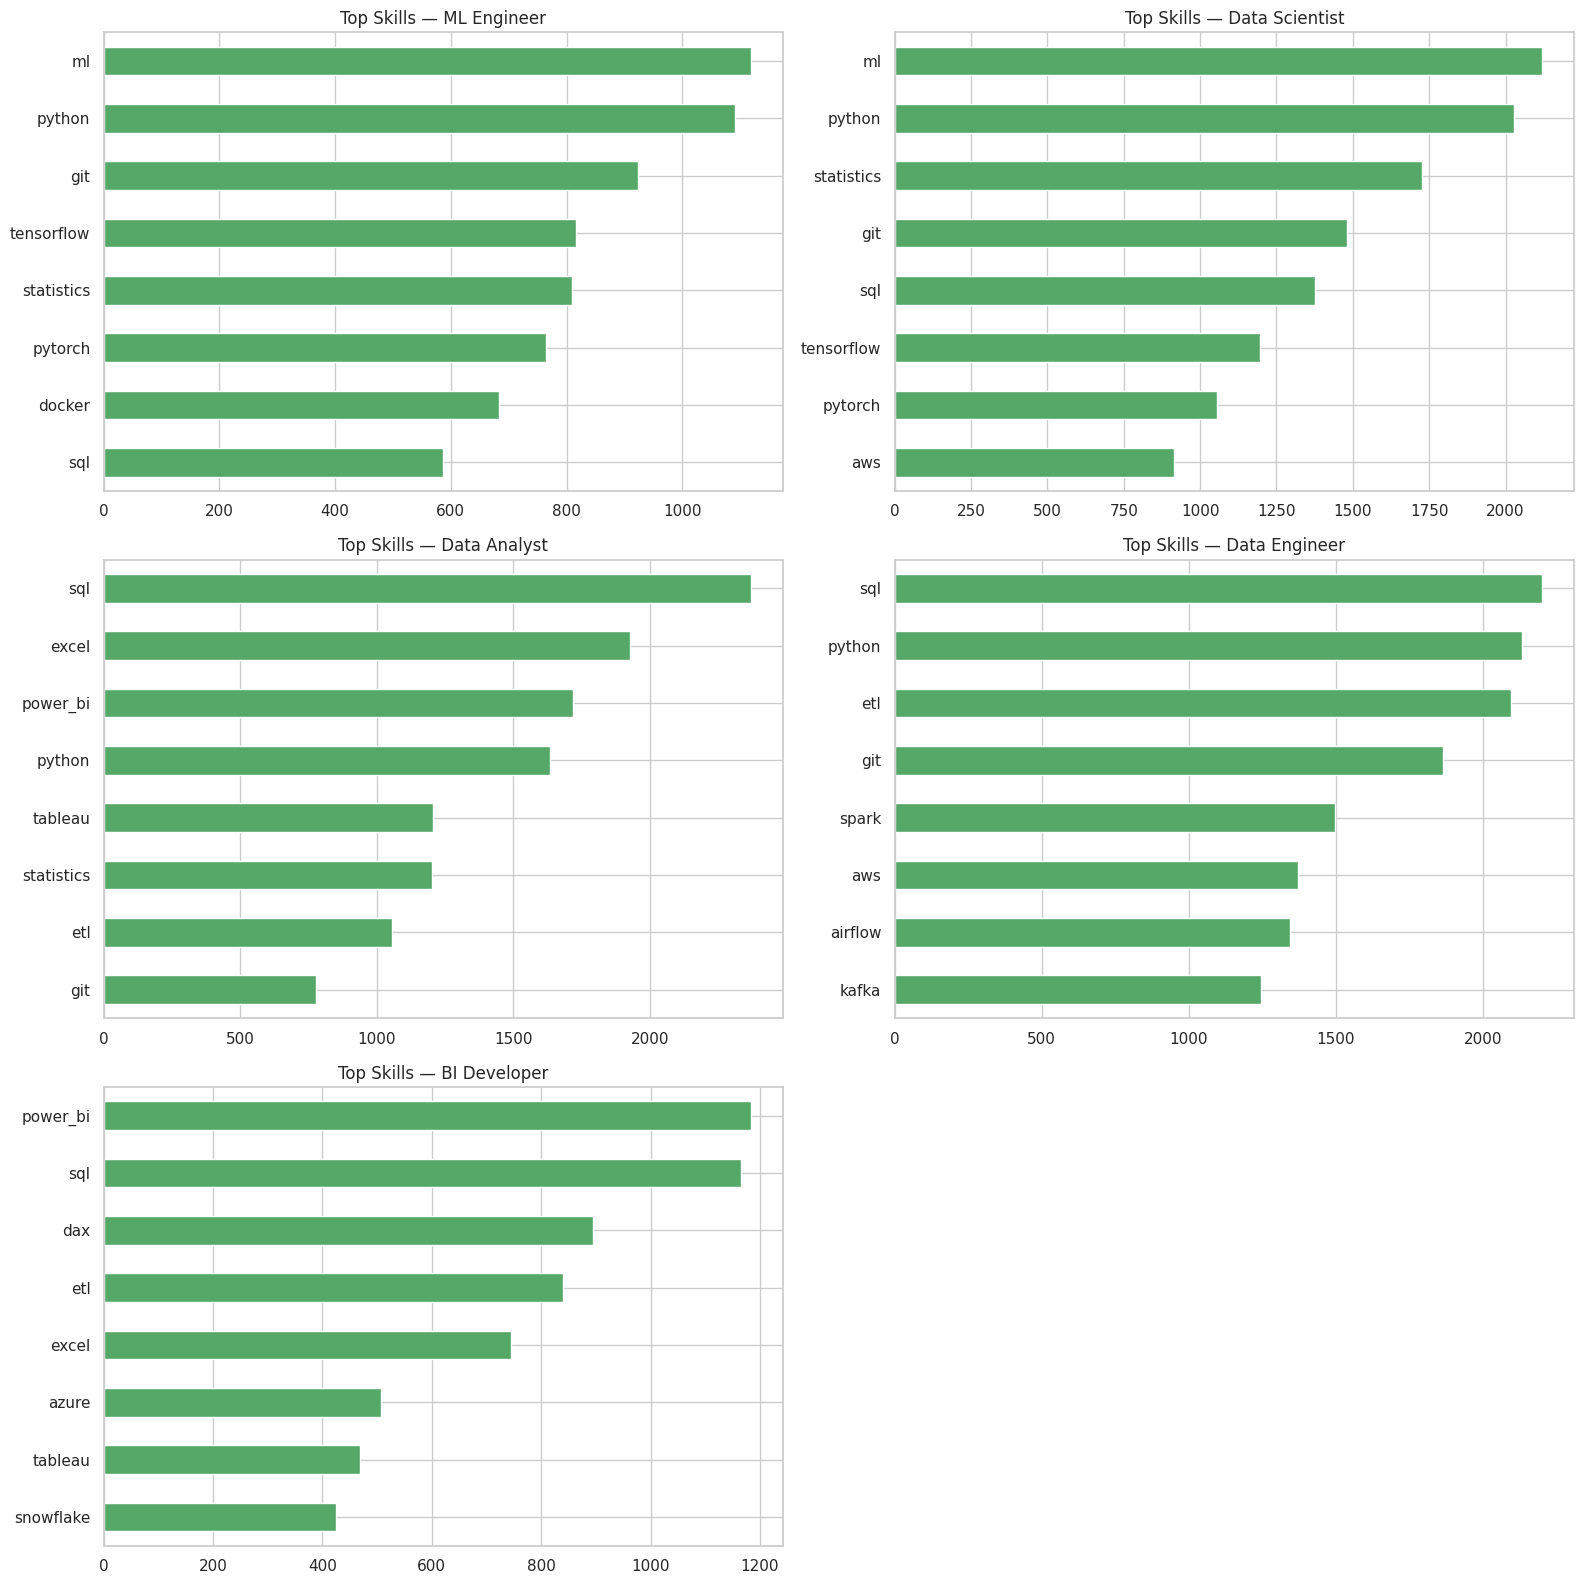

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()
for i, role in enumerate(df['role_category'].unique()):
    role_df = df[df['role_category'] == role]
    top_skills = role_df[skill_cols].sum().sort_values(ascending=False).head(8)
    top_skills.plot(kind='barh', ax=axes[i], color='#55A868')
    axes[i].set_title(f'Top Skills — {role}')
    axes[i].invert_yaxis()
fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig('../outputs/07_skills_by_role.png', dpi=120)
plt.show()

### 3.8 Do more required skills correlate with higher salary?

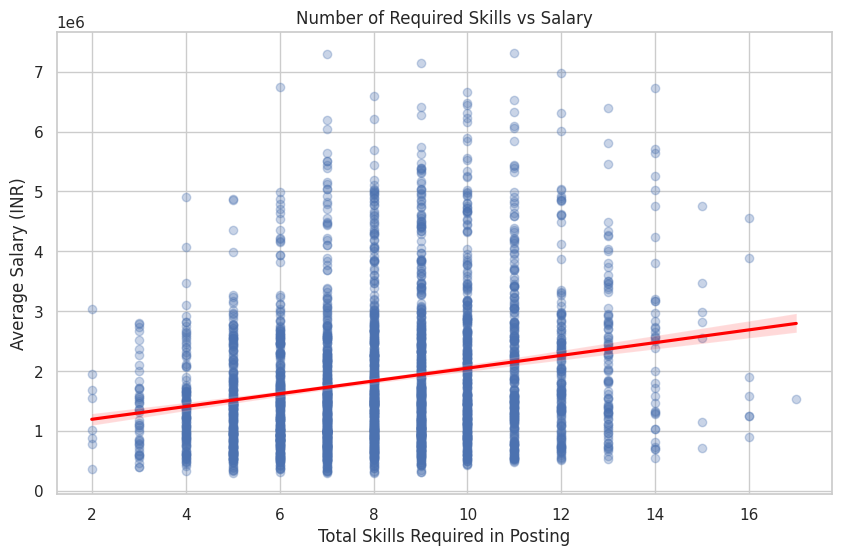

Correlation: 0.22


In [18]:
plt.figure(figsize=(10,6))
sns.regplot(data=salary_df, x='total_skills_required', y='salary_avg',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Number of Required Skills vs Salary')
plt.xlabel('Total Skills Required in Posting')
plt.ylabel('Average Salary (INR)')
plt.savefig('../outputs/08_skills_count_vs_salary.png', dpi=120)
plt.show()

print("Correlation:", salary_df['total_skills_required'].corr(salary_df['salary_avg']).round(3))

### 3.9 Which skills command the highest salary premium?

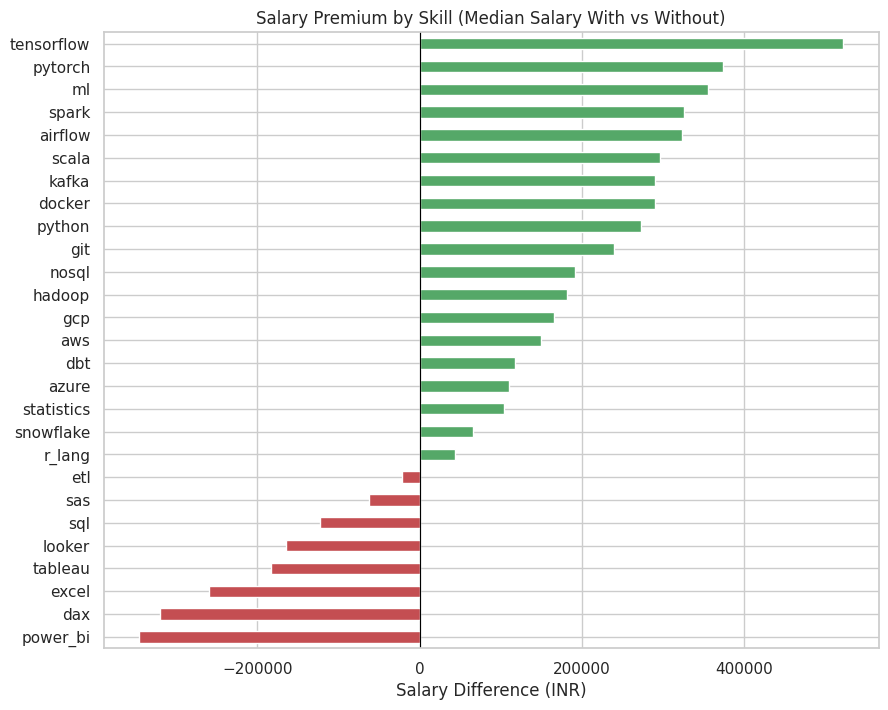

tensorflow    521881.0
pytorch       374054.0
ml            355307.0
spark         326101.0
airflow       323118.0
scala         295889.0
kafka         290340.0
docker        289707.0
python        272632.0
git           238694.0
nosql         191723.0
hadoop        180780.0
gcp           165949.0
aws           149131.0
dbt           116845.0
azure         109481.0
statistics    103818.0
snowflake      65106.0
r_lang         42920.0
etl           -22386.0
sas           -62080.0
sql          -123385.0
looker       -164414.0
tableau      -183028.0
excel        -260123.0
dax          -320388.0
power_bi     -346240.0
dtype: float64

In [19]:
skill_premium = {}
overall_median = salary_df['salary_avg'].median()
for s in skill_cols:
    with_skill = salary_df[salary_df[s] == 1]['salary_avg'].median()
    without_skill = salary_df[salary_df[s] == 0]['salary_avg'].median()
    skill_premium[s] = with_skill - without_skill

premium_series = pd.Series(skill_premium).sort_values(ascending=False)
plt.figure(figsize=(10,8))
premium_series.plot(kind='barh', color=premium_series.apply(lambda x: '#55A868' if x>0 else '#C44E52'))
plt.title('Salary Premium by Skill (Median Salary With vs Without)')
plt.xlabel('Salary Difference (INR)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.savefig('../outputs/09_skill_salary_premium.png', dpi=120)
plt.show()
premium_series.round(0)

### 3.10 Hiring trend over time

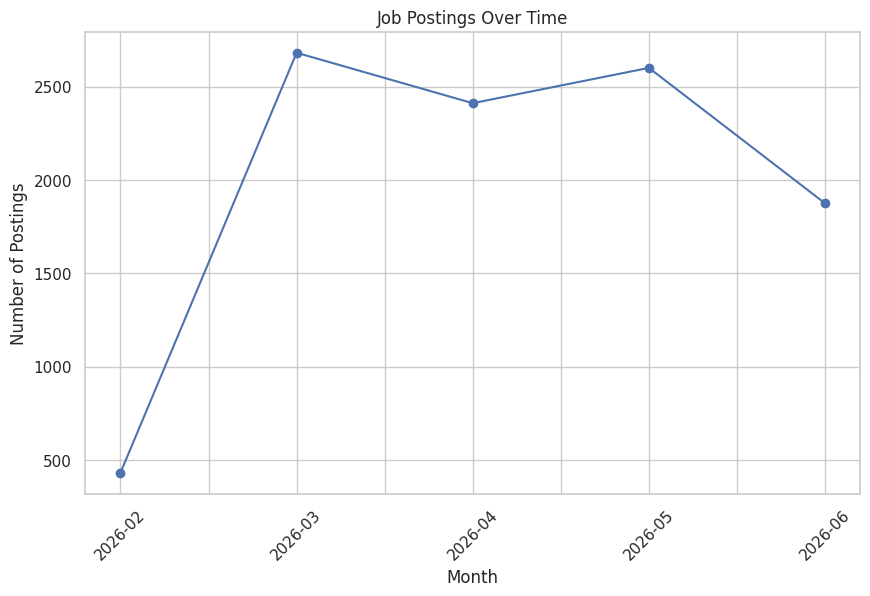

In [20]:
monthly = df.groupby('post_month').size()
plt.figure(figsize=(10,6))
monthly.plot(kind='line', marker='o', color='#4C72B0')
plt.title('Job Postings Over Time')
plt.ylabel('Number of Postings')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.savefig('../outputs/10_hiring_trend.png', dpi=120)
plt.show()

### 3.11 Top hiring companies

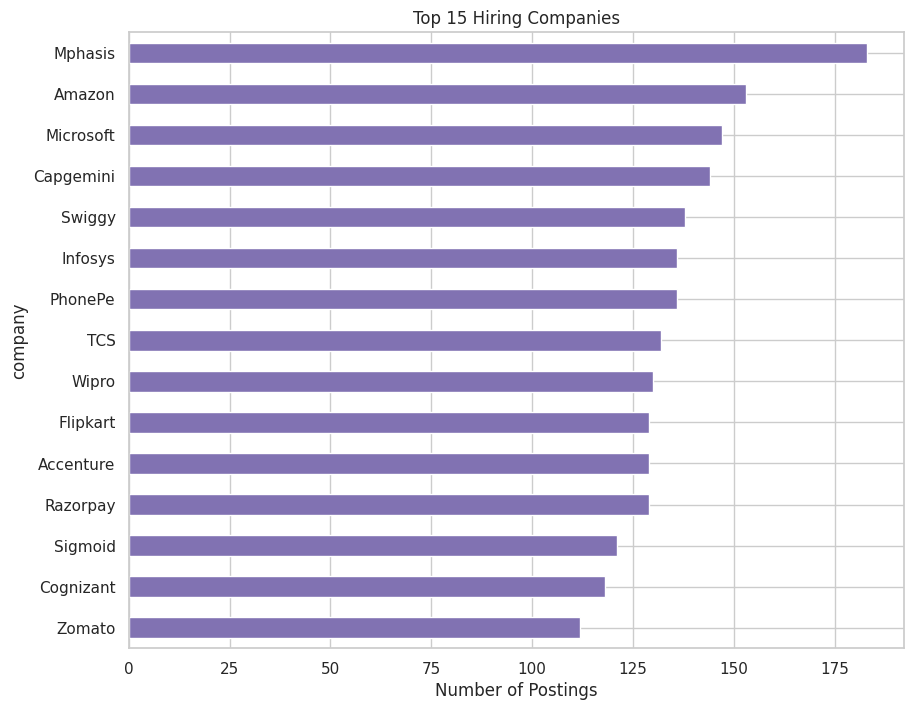

In [21]:
top_companies = df['company'].value_counts().head(15)
plt.figure(figsize=(10,8))
top_companies.plot(kind='barh', color='#8172B2')
plt.title('Top 15 Hiring Companies')
plt.xlabel('Number of Postings')
plt.gca().invert_yaxis()
plt.savefig('../outputs/11_top_companies.png', dpi=120)
plt.show()

### 3.12 Correlation heatmap (skills)

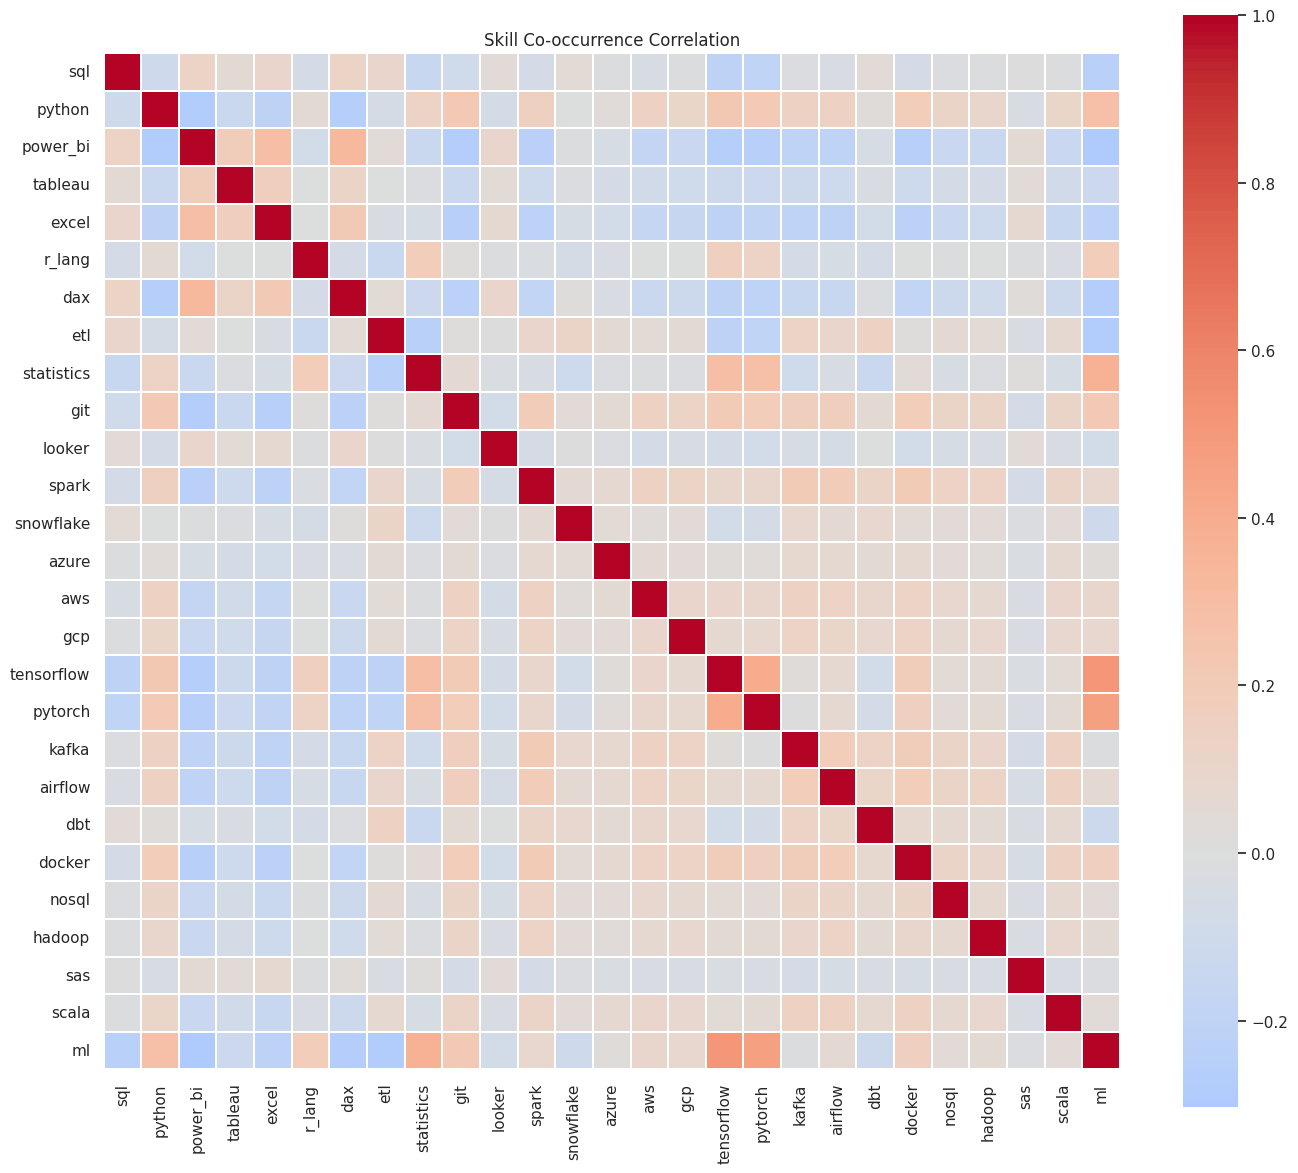

In [22]:
plt.figure(figsize=(14,12))
corr = df[skill_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, square=True)
plt.title('Skill Co-occurrence Correlation')
plt.tight_layout()
plt.savefig('../outputs/12_skill_correlation.png', dpi=120)
plt.show()

## 4. Key Insights

1. **Salary transparency is low** — only **29.8%** of postings disclose salary, and this holds consistently across all job types (contractual, full-time, permanent, temporary, part-time), suggesting non-disclosure is a general Indian tech-hiring norm rather than something tied to a specific job type.

2. **Experience is the strongest driver of salary** — experience and salary have a strong positive correlation (**r = 0.72**), versus a much weaker correlation between the number of skills listed and salary (**r = 0.22**). Employers pay primarily for seniority/experience, not for how many tools a posting lists.

3. **Role category drives pay tiers** — median salary ranking is **ML Engineer (₹21.99L) > Data Engineer (₹18.97L) > Data Scientist (₹17.45L) > BI Developer (₹12.01L) ≈ Data Analyst (₹11.98L)**. ML/DS specialization commands roughly an 80% premium over Analyst/BI roles.

4. **Core tools remain dominant baseline skills** — SQL (76.9% of postings) and Python (73.0%) are required in the vast majority of listings, followed by Git (53.4%), ETL (47.6%), Statistics (43.2%), and ML (42.9%). These are table-stakes, not differentiators.

5. **Specialized skills carry a real salary premium** — TensorFlow (+₹5.2L median), PyTorch (+₹3.7L), general ML (+₹3.6L), Spark (+₹3.3L), Airflow (+₹3.2L), Scala (+₹3.0L), Kafka (+₹2.9L), and Docker (+₹2.9L) each push median salary up notably versus postings that don't require them. These are the skills worth prioritizing for pay growth beyond SQL/Python.

6. **BI/reporting tools show a negative salary association** — Power BI (-₹3.5L), DAX (-₹3.2L), Excel (-₹2.6L), Tableau (-₹1.8L), and Looker (-₹1.6L) postings have *lower* median salaries than postings without them. This doesn't mean the tools are worthless — it reflects that they're concentrated in lower-paying Analyst/BI roles rather than higher-paying ML/Engineering roles.

7. **Bangalore leads hiring volume** (2,209 postings), followed by Mumbai (1,673) and Hyderabad (1,610). But **Gurugram has the highest median salary (₹16.08L)** despite ranking 5th in volume, followed by Bangalore (₹15.48L) — showing volume and pay are not perfectly correlated; Gurugram (NCR) pays a premium relative to its posting count.

8. **Skill co-occurrence clusters** — the correlation heatmap reveals natural stacks: cloud/big-data tools (Spark, Kafka, Airflow, Hadoop) tend to appear together, and BI tools (Power BI, Tableau, DAX) cluster together — useful for understanding which tech "stacks" employers expect as a bundle rather than in isolation.

## 5. Next Steps / Possible Extensions
- Build a salary prediction model (regression) using experience, role, city, and skills as features
- Cluster job postings into "skill archetypes" using the skill co-occurrence matrix (k-modes / PCA)
- Track skill-demand trend over time if more historical data becomes available
- Build an interactive dashboard (Streamlit/Power BI) on top of this cleaned dataset
